# Charge-per-cycle & actuation efficiency: PPy-in-tissue vs pure PPy film — **LENGTH / isotonic**

Companion to `cv_FORCE_charge_comparison.ipynb`. Same diagnostic, but on the **isotonic (LENGTH)** runs:
integrate the current over the *last* CV cycle for charge passed, and measure the **strain swing** and
whether it is **coherent with the applied potential** (real redox actuation) or just drift/creep.

> *Low charge density -> electrical access problem (percolation/loading).
> Healthy charge but bad strain -> downstream problem (diffusion or coupling).
> **Strain-per-charge** is the canonical CP-actuator efficiency metric.*

**Samples (LENGTH signal on CH1; calibrations differ between runs):**
- **TISSUE** = PPy in decell tissue. `05.22.26-neg25C_in_tissue_LENGTH`, 3 mV/s, 3 cycles. Captured at **10x gain** -> −0.04130 mm/V, L0 = 4.0 mm.
- **FILM** = pure distilled-pyrrole PPy ("golden child"). `06.03.26-neg25C_distilledpyrrole_LENGTH`, 2.5 mV/s, 3 cycles. Captured at **1x gain** -> −0.4130 mm/V, L0 = 3.5 mm.

Distance/strain are linear rescalings of the scope voltage (no baseline subtraction) — read the *swing* across the cycle as actuation.

In [1]:
import io, csv
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

SAMPLES = {
 'TISSUE 05.22 (PPy in decell)': dict(
    poten='Potentiostat_measurements/05.22.26-neg25C_in_tissue_LENGTH_3mVpersec.csv',
    scope='scope_log_20260522_165959_successful_-25C_PPy_electrochem_in_tissue_1chempol_-25C_buffered_LENGTH.csv',
    scan_rate=0.003, coef_mm_per_V=-0.4130/10.0, L0_mm=4.0),   # 10x gain
 'TISSUE 06.15 (2-day decell)': dict(
    poten='Potentiostat_measurements/06.15.26-2Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv',
    scope='scope_log_20260615_170309_2Day_10%_formalin_2.5mVperSecond_LENGTH.csv',
    scan_rate=0.0025, coef_mm_per_V=-0.4130/10.0, L0_mm=9.0),  # 10x gain
 'FILM (pure PPy)': dict(
    poten='Potentiostat_measurements/06.03.26-neg25C_distilledpyrrole_LENGTH_2.5mVpersec.csv',
    scope='scope_log_20260603_160853_neg25C-distilledppy_golden_child_LENGTH.csv',
    scan_rate=0.0025, coef_mm_per_V=-0.4130, L0_mm=3.5),       # 1x gain
}
SCOPE_CHANNEL = 'ch1_MEAN_V'   # LENGTH signal on CH1

def load_poten(path):
    with open(path,'rb') as f: text=f.read().decode('utf-16').replace('﻿','')
    rows=[r for r in csv.reader(io.StringIO('\n'.join(text.splitlines()[6:]))) if r and r[0]]
    n=len(rows[0])//2
    cols=[]; [cols.extend([f'v{s+1}', f'i{s+1}_uA']) for s in range(n)]
    return pd.DataFrame([[float(x) for x in r[:2*n]] for r in rows], columns=cols), n

def derive_dt(poten, sr):
    v1=poten['v1'].values; turn=int(np.argmin(v1))
    return abs(v1[0]-v1[turn])/turn/sr

In [2]:
# ---- Last-cycle charge (+ ohmic/non-ohmic split) and coherent strain swing ----
def analyze(s):
    poten, n = load_poten(s['poten'])
    dt = derive_dt(poten, s['scan_rate']); per = len(poten)*dt
    v = poten[f'v{n}'].values; i_uA = poten[f'i{n}_uA'].values   # last cycle
    i_A = i_uA*1e-6; t = np.arange(len(i_A))*dt

    q_anodic   = np.trapezoid(np.clip(i_A,0,None), t)*1e3        # mC
    q_cathodic = np.trapezoid(np.clip(-i_A,0,None), t)*1e3
    q_mean = 0.5*(q_anodic+q_cathodic)

    A=np.vstack([v,np.ones_like(v)]).T
    slope,inter = np.linalg.lstsq(A,i_uA,rcond=None)[0]; pred=A@np.array([slope,inter])
    r2 = 1-np.sum((i_uA-pred)**2)/np.sum((i_uA-i_uA.mean())**2)
    q_ohmic  = np.trapezoid(np.abs(pred*1e-6), t)*1e3
    q_nonohm = np.trapezoid(np.abs((i_uA-pred)*1e-6), t)*1e3
    R_ohm = 1.0/(slope*1e-6); frac_nonohm = q_nonohm/(q_ohmic+q_nonohm)

    # strain swing over last cycle + coherence with applied potential
    sc=pd.read_csv(s['scope']); sc_t=sc['elapsed_s'].values
    t_full=np.concatenate([np.arange(len(poten))*dt+k*per for k in range(n)])
    v_full=np.concatenate([poten[f'v{k+1}'].values for k in range(n)])
    m=(sc_t>=(n-1)*per)&(sc_t<n*per); ys_t=sc_t[m]; y=sc[SCOPE_CHANNEL].values[m]
    order=np.argsort(ys_t); ys_t=ys_t[order]; y=y[order]
    w=min(151,len(y)); w=w-1 if w%2==0 else w; ysm=savgol_filter(y,w,3)
    vapp=np.interp(ys_t,t_full,v_full)
    dist_mm = ysm*s['coef_mm_per_V']                       # apply calibration
    swing_mm = dist_mm.max()-dist_mm.min()
    strain_pct = swing_mm/s['L0_mm']*100
    noise_mm = np.std((y-ysm)*s['coef_mm_per_V'])
    coherence = np.corrcoef(dist_mm, vapp)[0,1]

    return dict(n_cycles=n, dt=dt, cycle_s=per, R_ohm=R_ohm, r2_ohmic=r2,
        i_peak_uA=np.abs(i_uA).max(), q_anodic_mC=q_anodic, q_cathodic_mC=q_cathodic,
        q_mean_mC=q_mean, q_ohmic_mC=q_ohmic, q_nonohmic_mC=q_nonohm, frac_nonohmic=frac_nonohm,
        swing_mm=swing_mm, strain_pct=strain_pct, noise_mm=noise_mm, snr=swing_mm/noise_mm,
        coherence_strain_V=coherence,
        strain_per_charge_pct_mC=strain_pct/q_mean,
        strain_per_nonohmCharge=strain_pct/(q_nonohm/2),
        v=v, i_uA=i_uA, pred=pred, dist_mm=dist_mm, vapp=vapp)

res={name:analyze(s) for name,s in SAMPLES.items()}
keys=['n_cycles','cycle_s','i_peak_uA','R_ohm','r2_ohmic',
      'q_anodic_mC','q_cathodic_mC','q_mean_mC','q_ohmic_mC','q_nonohmic_mC','frac_nonohmic',
      'swing_mm','strain_pct','noise_mm','snr','coherence_strain_V',
      'strain_per_charge_pct_mC','strain_per_nonohmCharge']
tbl=pd.DataFrame({nm:{k:res[nm][k] for k in keys} for nm in res})
pd.set_option('display.float_format', lambda x:f'{x:,.4g}')
tbl

,TISSUE 05.22 (PPy in decell),TISSUE 06.15 (2-day decell),FILM (pure PPy)
n_cycles,3,3,3
cycle_s,"1,334","1,600","1,600"
i_peak_uA,"3,281","2,099",796.2
R_ohm,415.3,709.7,"2,467"
r2_ohmic,0.8138,0.6333,0.2749
q_anodic_mC,909,712.1,304.3
q_cathodic_mC,860.2,650.9,312
q_mean_mC,884.6,681.5,308.2
q_ohmic_mC,"1,606","1,128",324.4
q_nonohmic_mC,816.5,893.9,533.6


In [3]:
# ---- Headline metrics for all samples + FILM/<tissue> ratios ----
names = list(res)
film = next(n for n in names if 'FILM' in n)
tissues = [n for n in names if n != film]
metrics = ['q_mean_mC','q_nonohmic_mC','swing_mm','strain_pct','coherence_strain_V',
           'strain_per_charge_pct_mC','strain_per_nonohmCharge']

hdr = f'{"metric":26s}' + ''.join(f'{n[:18]:>20s}' for n in names)
hdr += ''.join(f'{"FILM/"+t.split()[0]+t.split()[1]:>16s}' for t in tissues)
print(hdr)
for k in metrics:
    row = f'{k:26s}' + ''.join(f'{res[n][k]:>20.4g}' for n in names)
    row += ''.join(f'{res[film][k]/res[t][k]:>16.3f}' for t in tissues)
    print(row)

metric                      TISSUE 05.22 (PPy   TISSUE 06.15 (2-da     FILM (pure PPy)FILM/TISSUE05.22FILM/TISSUE06.15
q_mean_mC                                884.6               681.5               308.2           0.348           0.452
q_nonohmic_mC                            816.5               893.9               533.6           0.654           0.597
swing_mm                              0.008705            0.006212               0.397          45.604          63.909
strain_pct                              0.2176             0.06902               11.34          52.119         164.338
coherence_strain_V                     0.02747             -0.4482             -0.6043         -21.998           1.348
strain_per_charge_pct_mC              0.000246           0.0001013             0.03681         149.609         363.407
strain_per_nonohmCharge              0.0005331           0.0001544             0.04251          79.744         275.288


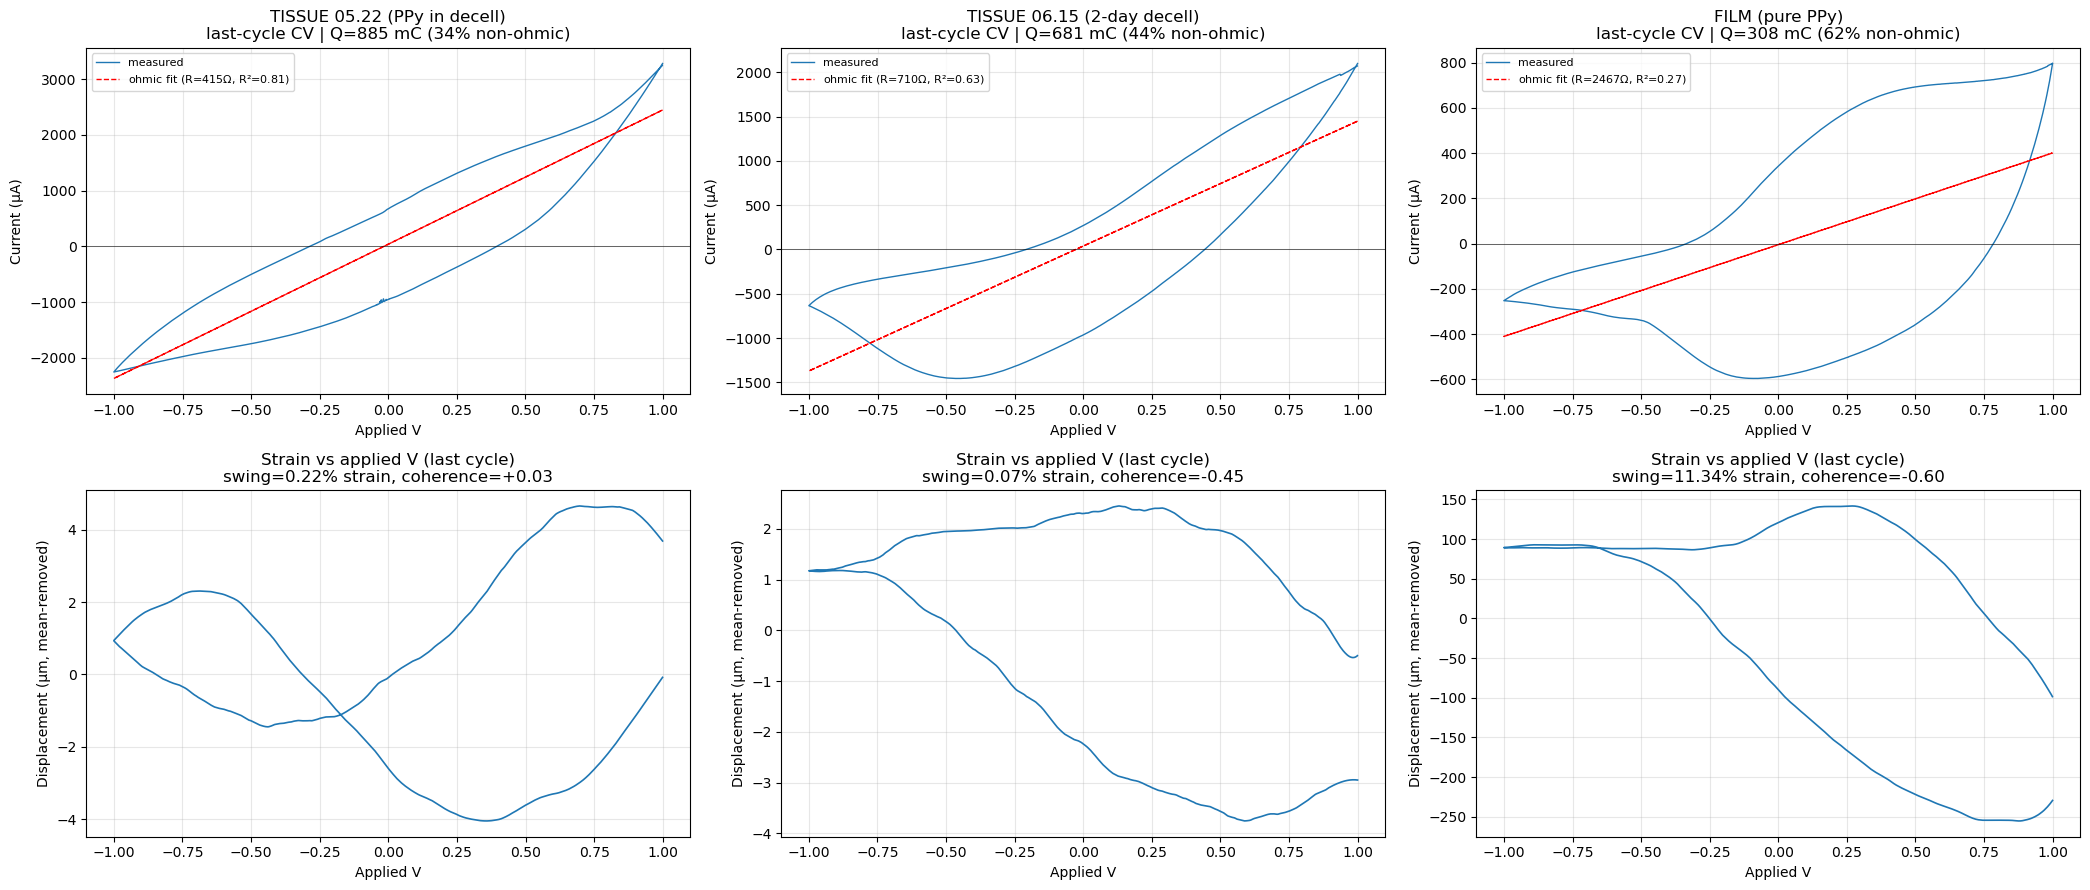

In [4]:
# ---- Visual: CV with ohmic backbone (top), strain-vs-potential coherence (bottom) ----
ncols = len(res)
fig,ax=plt.subplots(2,ncols,figsize=(7*ncols,9),squeeze=False)
for col,(nm,r) in enumerate(res.items()):
    ax[0,col].plot(r['v'],r['i_uA'],lw=1.0,label='measured')
    ax[0,col].plot(r['v'],r['pred'],'r--',lw=1,label=f"ohmic fit (R={r['R_ohm']:.0f}$\\Omega$, R²={r['r2_ohmic']:.2f})")
    ax[0,col].axhline(0,color='k',lw=.4)
    ax[0,col].set_title(f'{nm}\nlast-cycle CV | Q={r["q_mean_mC"]:.0f} mC ({r["frac_nonohmic"]*100:.0f}% non-ohmic)')
    ax[0,col].set_xlabel('Applied V'); ax[0,col].set_ylabel('Current (µA)'); ax[0,col].legend(fontsize=8); ax[0,col].grid(alpha=.3)
    ax[1,col].plot(r['vapp'], (r['dist_mm']-r['dist_mm'].mean())*1e3, lw=1.2)
    ax[1,col].set_title(f'Strain vs applied V (last cycle)\nswing={r["strain_pct"]:.2f}% strain, coherence={r["coherence_strain_V"]:+.2f}')
    ax[1,col].set_xlabel('Applied V'); ax[1,col].set_ylabel('Displacement (µm, mean-removed)'); ax[1,col].grid(alpha=.3)
fig.tight_layout(); plt.show()

## Read-out (isotonic)

Mirrors the FORCE/isometric result independently:

- **Tissue strain is incoherent with charge** (coherence ≈ 0): its small movement is drift/creep, **not redox-driven actuation**.
- **Film strain is coherent** (≈ −0.6) and large (**~11% strain**) — a healthy conducting-polymer actuator.
- **Same leakage signature** in a separate potentiostat run: tissue R ≈ 0.4 kΩ / ~80% ohmic vs film ≈ 2.5 kΩ / ~27% ohmic.
- **Strain-per-charge** (canonical CP-actuator efficiency) is ~100x+ worse for the tissue.

**Diagnosis (now confirmed in both isometric and isotonic mode):** excess, leaky charge with ~zero charge-coherent mechanical output -> the bottleneck is **downstream of charge injection (coupling + dilute loading)**, not electrical access. Next experiment: run a **blank decell tissue (no PPy)** CV + length trace to measure and subtract the leakage baseline.

## Update — the new **06.15 2-day-decell tissue** (LENGTH / isotonic)

- **Strain is now coherent with the redox cycle:** coherence **−0.45** (old tissue +0.03 ≈ noise; film −0.60). The free-displacement signal now has the right sign/phase — it's no longer pure drift.
- **But the magnitude is still tiny:** ~**0.07 % strain** (~6 µm swing), vs **11 %** for the film. In *isotonic* mode the new construct barely moves even though in *isometric* mode (FORCE notebook) it produces real, coherent force.
- That force-vs-displacement split is the classic stiff-actuator signature: the construct can push (force) but can't shorten much against ~zero load — consistent with a still-dilute / stiff PPy-in-tissue network.

⚠️ **Calibration caveat:** strain magnitude assumes the 06.15 LENGTH run was at **10× gain** (coef −0.04130 mm/V), per its run notes. If it was actually 1× gain, every strain/swing/strain-per-charge number for this sample is **10× larger**. Worth confirming the gain setting; it does not affect the coherence sign.
